# Lecture 5 - Solutions
Spectrogram colours show power spectral density on a logarithmic dB scale without peak normalisation. The simple first-half FFT amplitude expression doubles DC and omits the Nyquist bin. For odd sample counts, it also omits the highest positive-frequency bin. These FFT magnitudes are not power spectral density.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import urllib.request
import librosa
from IPython import display

## Exercise 1 - Spectrogram of a recording

Download and load an MP3 file of your choice in Python. Plot a spectrogram using the SciPy documentation below.

Use `librosa.load(file_name, sr=None)` to load the file at its original sample rate. The function returns the audio samples followed by the sample rate.

Source [SciPy spectrogram documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.spectrogram.html).


### Solution

Use the MP3 version of the same BigSoundBank recording 2345 as the supplied answer. Download it and load it with `librosa.load(file_name, sr=None)` to preserve the original sample rate. Librosa returns floating-point samples. Normalise them by their largest absolute value before playback and analysis.

Apply a Hann window of 2048 samples and plot the spectrogram with Gouraud shading, as in the original answer. Time runs horizontally, frequency vertically and brighter colours indicate stronger components. Convert the power spectral density to a logarithmic scale with `10 * log10`, without dividing by its maximum. The strongest component is therefore not forced to 0 dB.

`np.finfo(float).tiny` is the smallest positive normal value representable by NumPy's default floating-point type, approximately `2.225e-308`. `np.maximum(Sxx, np.finfo(float).tiny)` sets a positive lower bound before the logarithm. This prevents zero-power entries from producing `log10(0)`, which would give negative infinity. It is a numerical safeguard, not a normalisation step.

In [2]:
file_name = "2345.mp3"
url = f"https://bigsoundbank.com/UPLOAD/mp3/{file_name}"
urllib.request.urlretrieve(url, file_name)

sound_data, sample_rate = librosa.load(file_name, sr=None)
sound_data = sound_data / np.max(np.abs(sound_data))
display.display(display.Audio(data=sound_data, rate=sample_rate, normalize=False))

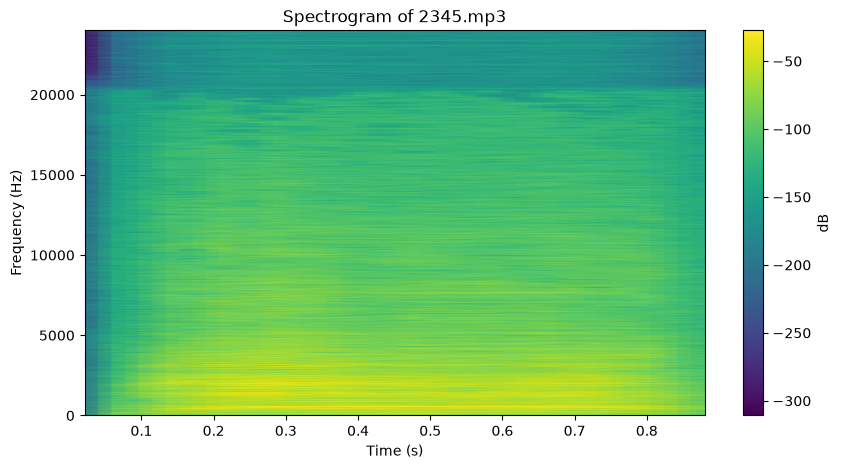

In [3]:
window = signal.windows.hann(2048)
f, t, Sxx = signal.spectrogram(sound_data, sample_rate, window=window)
Sxx_db = 10 * np.log10(np.maximum(Sxx, np.finfo(float).tiny))

plt.figure(figsize=(10, 5))
plt.pcolormesh(t, f, Sxx_db, shading="gouraud")
plt.colorbar().set_label("dB")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.title(f"Spectrogram of {file_name}")
plt.show()

## Exercise 2 - Combine two sinusoids

Create 11000 Hz and 11120 Hz sinusoids, both sampled at 44100 Hz with a total duration of five seconds. Combine the two sinusoids into one waveform.


### Solution

Generate both sinusoids at 44100 Hz for five seconds, then add their samples. Use `endpoint=False` so the sample spacing is exactly `1 / sample_rate`. Both frequencies are below the 22050 Hz Nyquist frequency.

The supplied answer also checks the combined waveform with a full FFT. Its first-half magnitude plot has a peak of 1 at each sinusoid frequency. For this even sample count, scaling by `2 / N` is equivalent to the original answer’s scaling by the inverse length of the first half.

In [4]:
sample_rate = 44100
duration = 5
frequency_1 = 11000
frequency_2 = 11120

def get_sine_data(frequency, sample_rate, duration):
    time = np.linspace(0, duration, duration * sample_rate, endpoint=False)
    sine = np.sin(2 * np.pi * frequency * time)
    return time, sine

_, sine_1 = get_sine_data(frequency_1, sample_rate, duration)
time, sine_2 = get_sine_data(frequency_2, sample_rate, duration)
combined_sine = sine_1 + sine_2

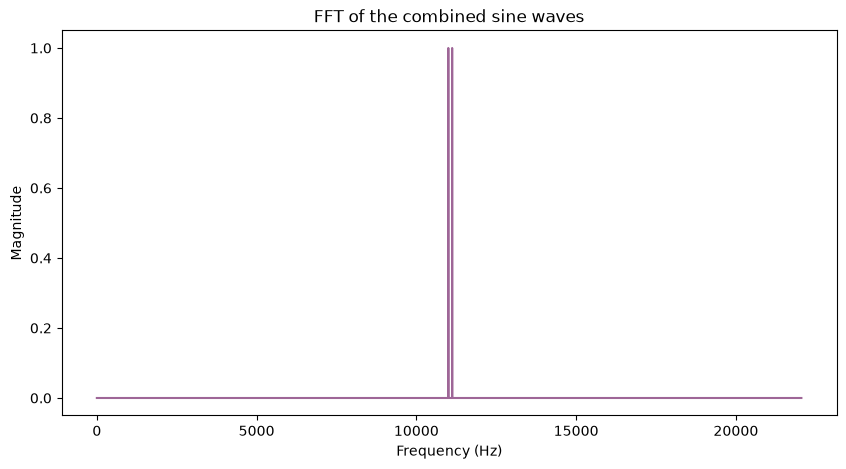

In [5]:
N = len(combined_sine)
fft_values = np.fft.fft(combined_sine)
fft_magnitude = 2 / N * np.abs(fft_values[:N // 2])
fft_freqs = np.fft.fftfreq(N, 1 / sample_rate)[:N // 2]

plt.figure(figsize=(10, 5))
plt.title("FFT of the combined sine waves")
plt.plot(fft_freqs, fft_magnitude, color="#9e6697")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

## Exercise 3 - Distinguish the two frequencies

Design and plot a spectrogram of the combined waveform from Exercise 2 in which the two frequencies are distinctly visible. For choosing which window to use, use this https://download.ni.com/evaluation/pxi/Understanding%20FFTs%20and%20Windowing.pdf.


### Solution

Use the original Hamming window of `2**15`, or 32768 samples. It spans approximately 0.743 seconds and gives a frequency-bin spacing of approximately 1.35 Hz. This is much smaller than the 120 Hz separation, and the two horizontal frequency bands are distinct.

Keep the original frequency-axis zoom from 10750 to 11400 Hz. A longer window improves frequency discrimination but reduces time localisation. Both tones are present throughout the five-second signal, so their bands remain horizontal. The plotted time axis shows the centres of complete analysis windows, not the signal endpoints.

Convert the power spectral density with `10 * log10` without peak normalisation, as in Exercise 1. Use the same tiny positive lower bound to avoid taking the logarithm of zero.

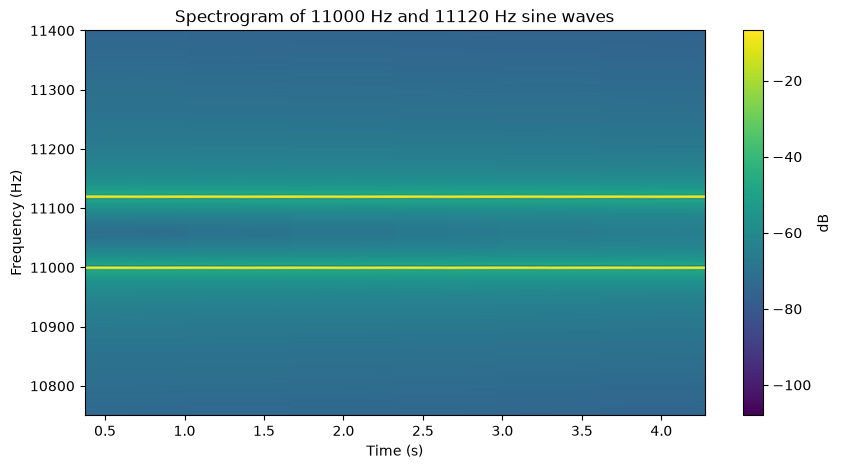

In [6]:
window = signal.windows.hamming(2**15)
f, t, Sxx = signal.spectrogram(combined_sine, sample_rate, window=window)
Sxx_db = 10 * np.log10(np.maximum(Sxx, np.finfo(float).tiny))

plt.figure(figsize=(10, 5))
plt.pcolormesh(t, f, Sxx_db, shading="gouraud")
plt.colorbar().set_label("dB")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.title("Spectrogram of 11000 Hz and 11120 Hz sine waves")
plt.ylim(10750, 11400)
plt.show()